
===  Motion Blur  ===
Inverse: (np.float64(13.65074028811679), np.float64(-11.351562040746742), np.float64(4.430491405421491e-05)) Time: 0.4939839839935303
Wiener: (np.float64(0.016993024220030774), np.float64(17.69729323591666), np.float64(0.5041692176615998)) Time: 0.4420583248138428
Lucy: (np.float64(0.006414470228578559), np.float64(21.9283920621123), np.float64(0.7911210367796074)) Time: 17.695975303649902


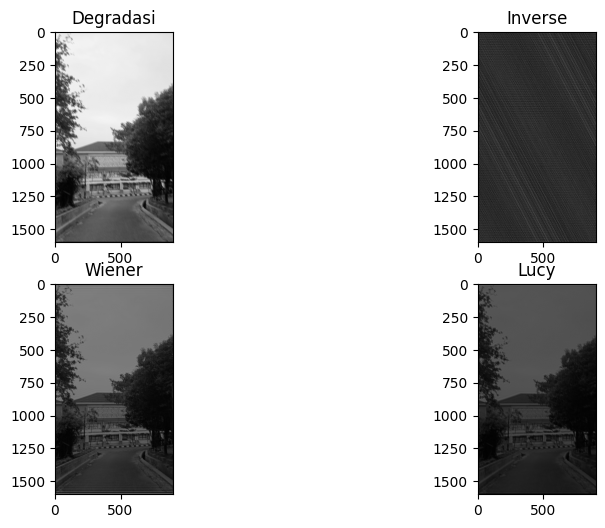


===  Gaussian + Blur  ===
Inverse: (np.float64(319301.7448453238), np.float64(-55.04201291776606), np.float64(4.929341215945246e-10)) Time: 0.3479745388031006
Wiener: (np.float64(0.07787648365972999), np.float64(11.085936663154916), np.float64(0.013056691667394083)) Time: 0.3230247497558594
Lucy: (np.float64(0.011217650491492087), np.float64(19.500980954355228), np.float64(0.263764613397414)) Time: 18.314919233322144


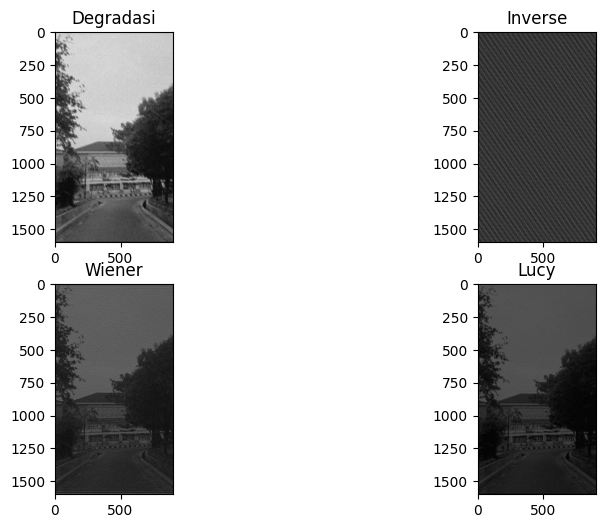


===  SP + Blur  ===
Inverse: (np.float64(1234922.8105106105), np.float64(-60.916398126426756), np.float64(2.9475874017367375e-10)) Time: 0.3226771354675293
Wiener: (np.float64(0.17207898943787495), np.float64(7.642721530787716), np.float64(0.006442856674840008)) Time: 0.3158149719238281
Lucy: (np.float64(0.01897245114567234), np.float64(17.21876556814468), np.float64(0.17849158269580842)) Time: 17.132694721221924


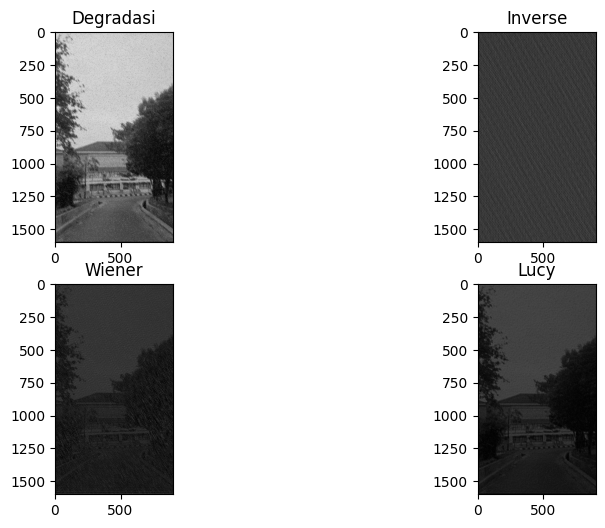

In [2]:
import cv2
import numpy as np
from scipy.signal import convolve2d
from skimage.metrics import peak_signal_noise_ratio, mean_squared_error, structural_similarity
from numpy.fft import fft2, ifft2
import matplotlib.pyplot as plt
import time

# Load image
img = cv2.imread('jalan.jpeg', 0)
img = img / 255.0

# PSF Motion Blur
def motion_psf(length, angle):
    psf = np.zeros((length, length))
    center = length // 2
    for i in range(length):
        psf[i, center] = 1
    M = cv2.getRotationMatrix2D((center, center), angle, 1)
    psf = cv2.warpAffine(psf, M, (length, length))
    return psf / psf.sum()

psf = motion_psf(15, 30)

# Degradasi
blur = convolve2d(img, psf, mode='same')

def gaussian_noise(img, sigma):
    noise = np.random.normal(0, sigma/255.0, img.shape)
    return np.clip(img + noise, 0, 1)

def sp_noise(img, prob):
    noisy = img.copy()
    rand = np.random.rand(*img.shape)
    noisy[rand < prob/2] = 0
    noisy[rand > 1 - prob/2] = 1
    return noisy

gaussian_blur = gaussian_noise(blur, 20)
sp_blur = sp_noise(blur, 0.05)

# Inverse Filtering
def inverse_filter(img, psf):
    G = fft2(img)
    H = fft2(psf, s=img.shape)
    H[H == 0] = 1e-6
    return np.abs(ifft2(G / H))

# Wiener Filter
def wiener_filter(img, psf, K):
    G = fft2(img)
    H = fft2(psf, s=img.shape)
    Hc = np.conj(H)
    return np.abs(ifft2((Hc / (np.abs(H)**2 + K)) * G))

# Lucy-Richardson
def lucy(img, psf, iter=10):
    estimate = np.full(img.shape, 0.5)
    psf_m = np.flipud(np.fliplr(psf))
    for _ in range(iter):
        conv = convolve2d(estimate, psf, 'same')
        estimate *= convolve2d(img/(conv+1e-6), psf_m, 'same')
    return estimate

# Evaluasi
def evaluate(original, restored):
    mse = mean_squared_error(original, restored)
    psnr = peak_signal_noise_ratio(original, restored)
    ssim = structural_similarity(original, restored, data_range=1)
    return mse, psnr, ssim

datasets = {
    "Motion Blur": blur,
    "Gaussian + Blur": gaussian_blur,
    "SP + Blur": sp_blur
}

for name, data in datasets.items():
    print("\n=== ", name, " ===")

    start = time.time()
    inv = inverse_filter(data, psf)
    print("Inverse:", evaluate(img, inv), "Time:", time.time()-start)

    start = time.time()
    wien = wiener_filter(data, psf, 0.01)
    print("Wiener:", evaluate(img, wien), "Time:", time.time()-start)

    start = time.time()
    lr = lucy(data, psf, 10)
    print("Lucy:", evaluate(img, lr), "Time:", time.time()-start)

    # Tampilkan gambar
    plt.figure(figsize=(10,6))
    plt.subplot(2,2,1); plt.title("Degradasi"); plt.imshow(data, cmap='gray')
    plt.subplot(2,2,2); plt.title("Inverse"); plt.imshow(inv, cmap='gray')
    plt.subplot(2,2,3); plt.title("Wiener"); plt.imshow(wien, cmap='gray')
    plt.subplot(2,2,4); plt.title("Lucy"); plt.imshow(lr, cmap='gray')
    plt.show()